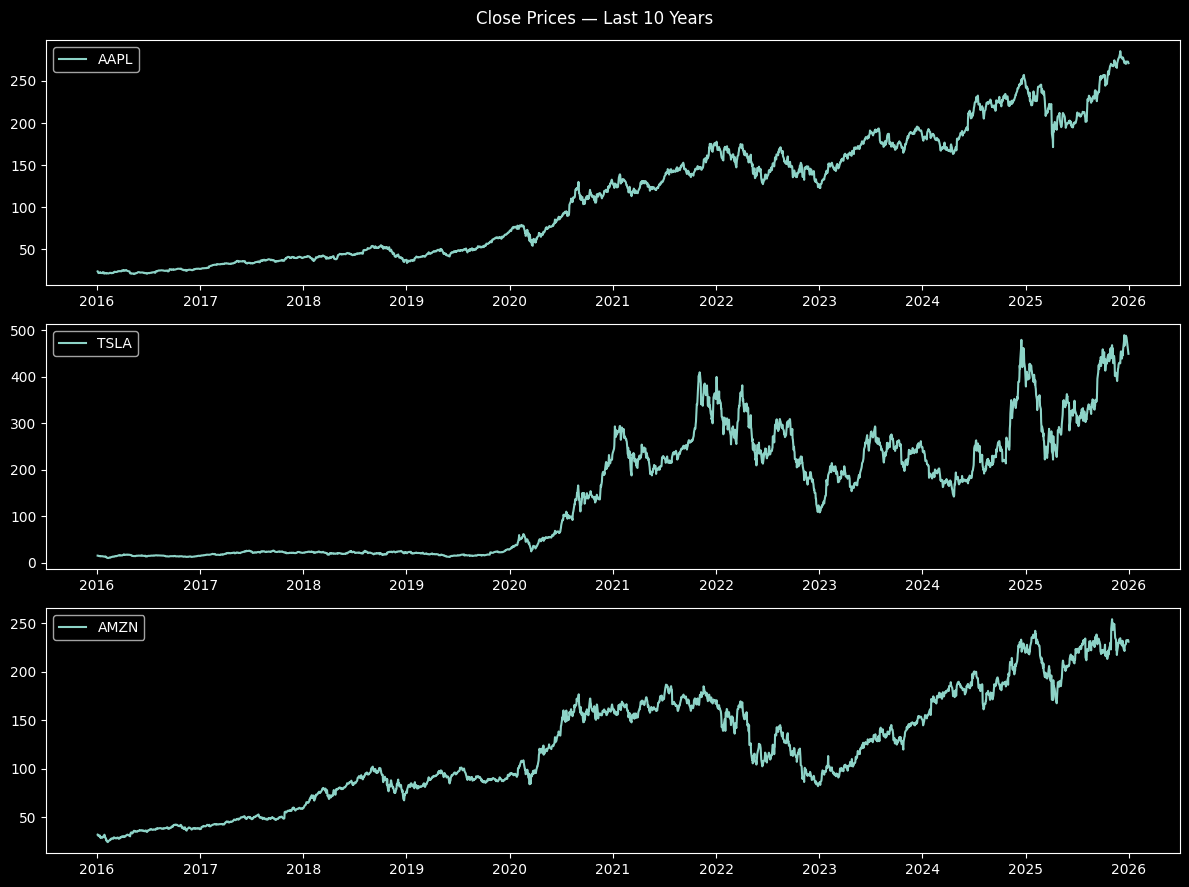

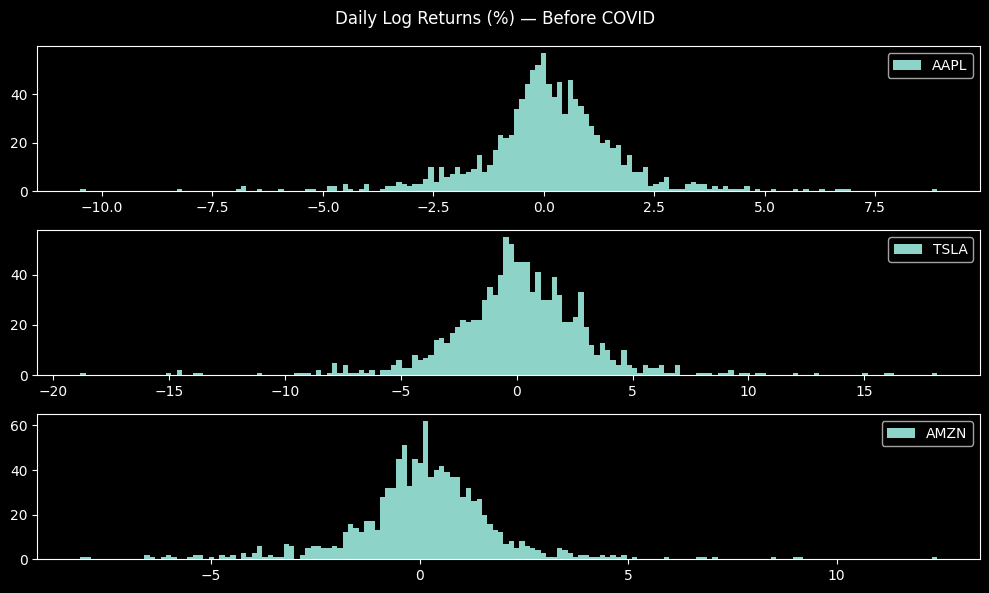


Before COVID
assets: 	 ['AAPL', 'TSLA', 'AMZN']
exp ret: 	 [24.68 24.97 25.14]
std: 		 [25.91 50.03 28.24]
skew: 		 [-0.38 -0.06  0.17]
kurt: 		 [8.37 9.2  8.9 ]


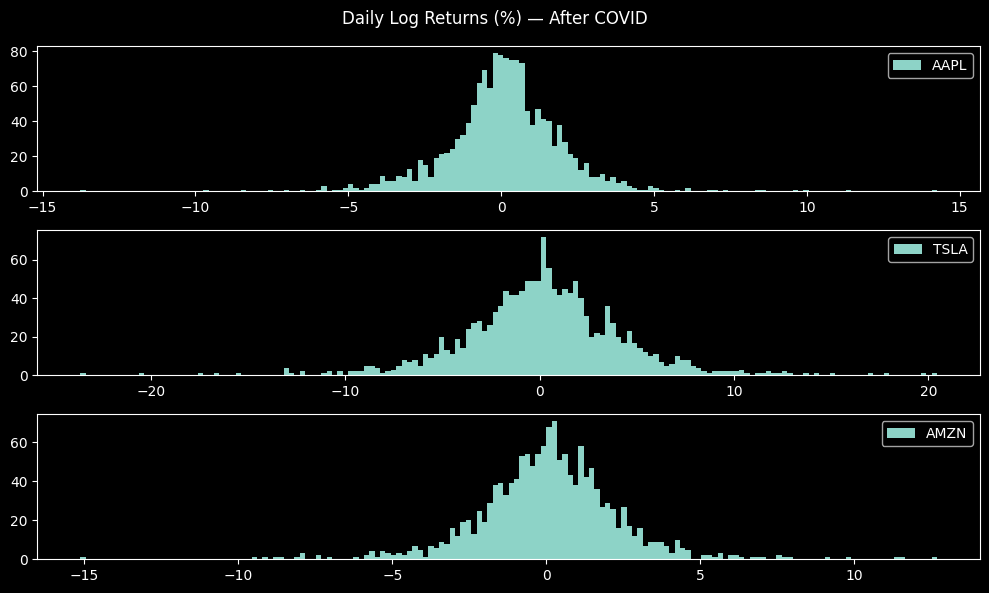


After COVID
assets: 	 ['AAPL', 'TSLA', 'AMZN']
exp ret: 	 [26.09 42.97 17.49]
std: 		 [30.76 64.65 35.48]
skew: 		 [ 0.13 -0.05 -0.06]
kurt: 		 [9.58 6.21 7.43]


In [1]:
import yfinance as yf
import matplotlib.pyplot as plt                                                           #Draws all the charts and graphs
import matplotlib.dates as mdates
import numpy as np                                                                        #Does fast math on lists of numbers
from scipy.stats import skew, kurtosis

plt.style.use('dark_background')                                                          #Set the style before creating any figure

v_assets = ['AAPL', 'TSLA', 'AMZN']
periods = {                                                                               #End date is exclusive
    'Before COVID': ('2016-01-01', '2020-03-12'),
    'After COVID':  ('2020-03-12', '2026-01-01')
}

#Download all prices once; columns are aligned by date
close = yf.download(v_assets, start = '2016-01-01', end = '2026-01-01',
                    auto_adjust = True, progress = False)['Close'][v_assets]

plt.figure(figsize = (12, 9))
plt.suptitle('Close Prices Last 10 Years')
for i, ticker in enumerate(v_assets):
    plt.subplot(3, 1, i + 1)
    plt.plot(close[ticker], label = ticker)
    plt.legend(loc = 2)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()                                                                        #Automatically adjusts spacing between subplots
plt.show()

for period, (start, end) in periods.items():
    m_close = close[(close.index >= start) & (close.index < end)].dropna()
    m_log_ret = np.log(m_close / m_close.shift(1)).dropna().to_numpy()                    #Daily log returns, rows = days, cols = assets

    plt.figure(figsize = (10, 6))
    plt.suptitle(f'Daily Log Returns (%) {period}')
    for i in range(len(v_assets)):
        plt.subplot(3, 1, i + 1)
        plt.hist(100 * m_log_ret[:, i], label = v_assets[i], bins = 160)                  #[:,i]=[all the returns,i]
        plt.legend(loc = 1)
    plt.tight_layout()
    plt.show()

    print(f'\n{period}')
    print('assets: \t', v_assets)
    print('exp ret: \t', np.round(100 * np.mean(m_log_ret, axis = 0) * 252, 2))           #Average yearly profit in percent
    print('std: \t\t', np.round(100 * np.std(m_log_ret, axis = 0) * np.sqrt(252), 2))     #Risk (how much the stock price jumps around)
    print('skew: \t\t', np.round(skew(m_log_ret), 2))                                     #Big losses or big gains are more extreme
    print('kurt: \t\t', np.round(kurtosis(m_log_ret, fisher = False), 2))                 #How often extreme days happen(a perfectly normal distribution = 3)